# Project Overview

This project predicts product sales based on advertising expenditure across different marketing channels. 

The objective is to understand how advertising investments influence sales and build a machine learning model capable of forecasting future sales.

In [1]:
# Import libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
        mean_absolute_error,
        mean_squared_error,
        r2_score
)

In [2]:
# Load Dataset

df = pd.read_csv("data/advertising.csv")

df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [3]:
# Data Understanding
print('Row & column:',df.shape)
print('Infomation:',df.info())
print('Describe:',df.describe())
print('Missing value:',df.isnull().sum())
print('Duplicate check:',df.duplicated().sum())

Row & column: (200, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB
Infomation: None
Describe:        Unnamed: 0          TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000  200.000000
mean   100.500000  147.042500   23.264000   30.554000   14.022500
std     57.879185   85.854236   14.846809   21.778621    5.217457
min      1.000000    0.700000    0.000000    0.300000    1.600000
25%     50.750000   74.375000    9.975000   12.750000   10.375000
50%    100.500000  149.750000   22.900000   25.750000   12.900000
75%    150.250000  218.825000   36.525000   45.

In [4]:
df.drop('Unnamed: 0', axis=1, inplace=True)

df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [5]:
# Exploratory Data Analysis(EDA)


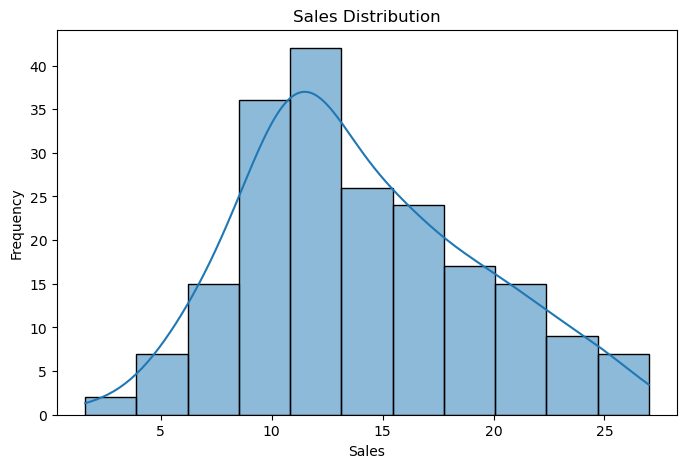

In [6]:
#sales Distribution
plt.figure(figsize=(8,5))

sns.histplot(df["Sales"], kde=True)

plt.title("Sales Distribution")
plt.xlabel('Sales')
plt.ylabel('Frequency')

plt.show()

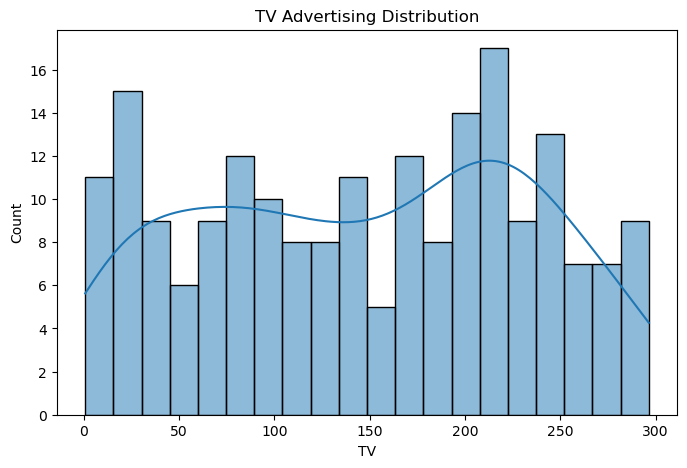

In [7]:
# Adverstising budjet distribution
#TV
plt.figure(figsize=(8,5))

sns.histplot(df['TV'], bins=20, kde=True)

plt.title('TV Advertising Distribution')

plt.show()

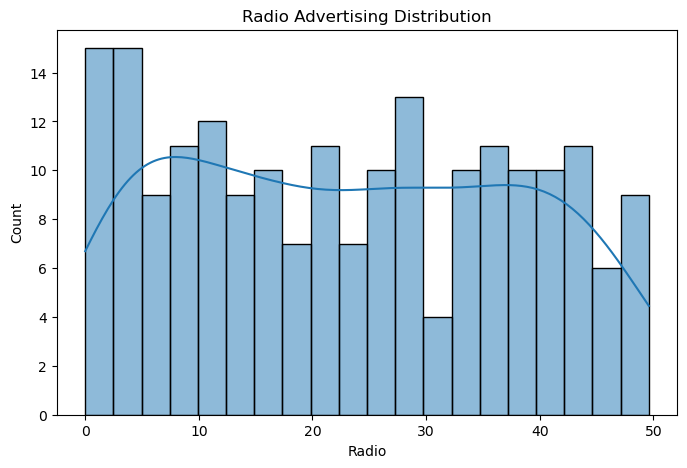

In [8]:
# Radio
plt.figure(figsize=(8,5))

sns.histplot(df['Radio'], bins=20, kde=True)

plt.title('Radio Advertising Distribution')

plt.show()

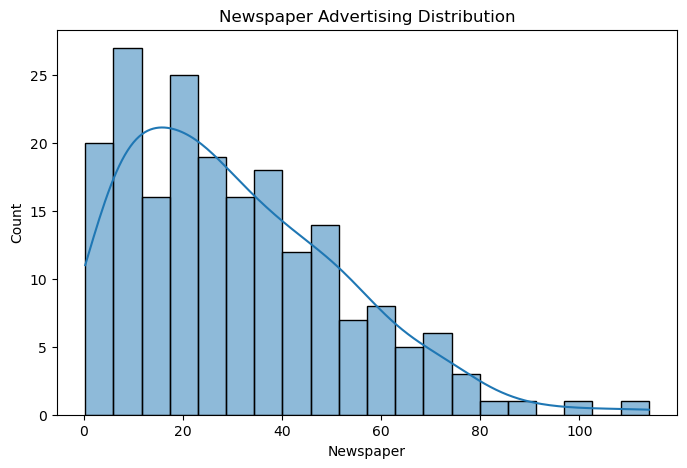

In [9]:
# Newspaper
plt.figure(figsize=(8,5))

sns.histplot(df['Newspaper'], bins=20, kde=True)

plt.title('Newspaper Advertising Distribution')

plt.show()

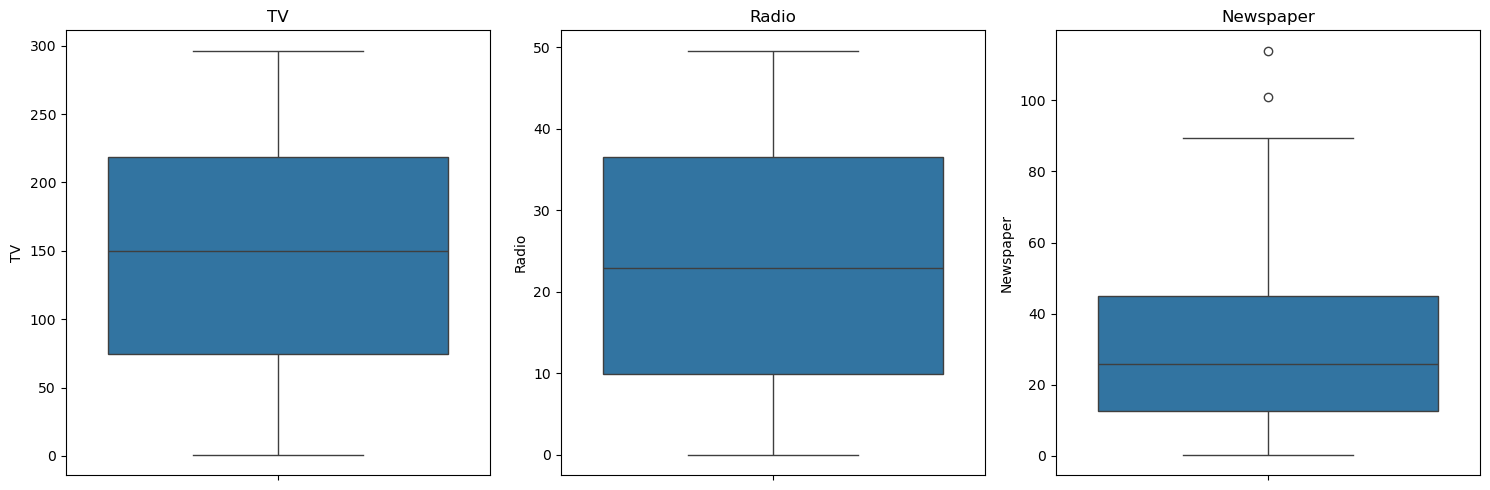

In [10]:
# Boxplots (Outlier Detection)
fig, ax = plt.subplots(1,3, figsize=(15,5))

sns.boxplot(y=df['TV'], ax=ax[0])
ax[0].set_title('TV')

sns.boxplot(y=df['Radio'], ax=ax[1])
ax[1].set_title('Radio')

sns.boxplot(y=df['Newspaper'], ax=ax[2])
ax[2].set_title('Newspaper')

plt.tight_layout()

plt.show()

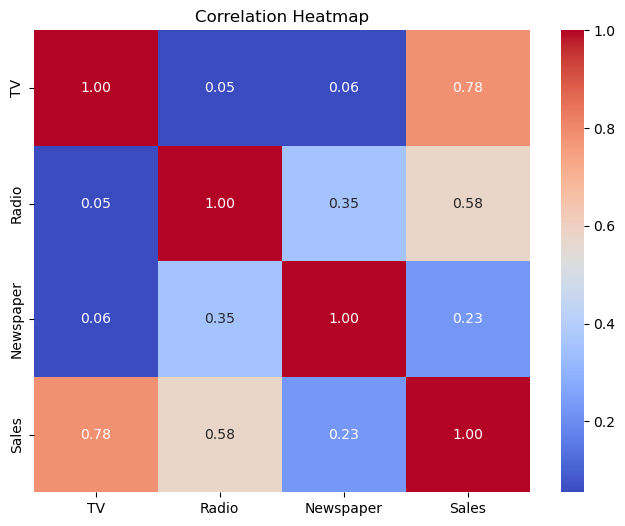

In [11]:
# Correlation Heatmap
plt.figure(figsize=(8,6))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')

plt.show()

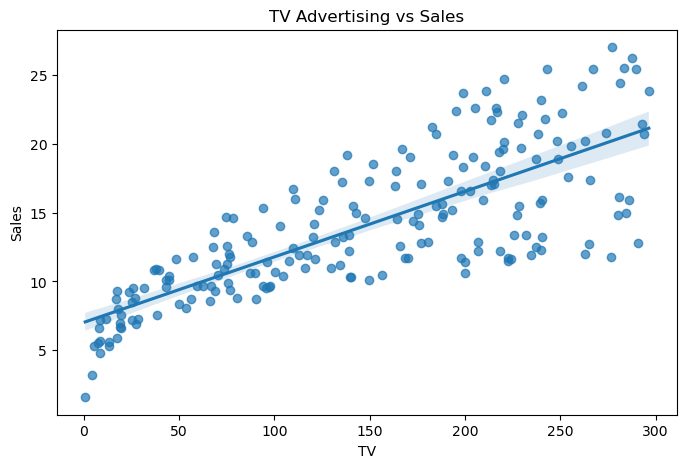

In [12]:
# TV vs Sales
plt.figure(figsize=(8,5))

sns.regplot(
    data=df,
    x='TV',
    y='Sales',
    scatter_kws={'alpha':0.7}
)

plt.title('TV Advertising vs Sales')

plt.show()

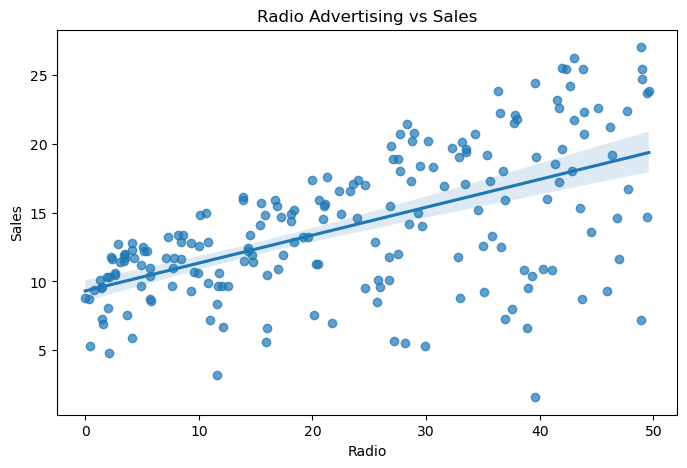

In [13]:
# Radio vs sales
plt.figure(figsize=(8,5))

sns.regplot(
    data=df,
    x='Radio',
    y='Sales',
    scatter_kws={'alpha':0.7}
)

plt.title('Radio Advertising vs Sales')

plt.show()

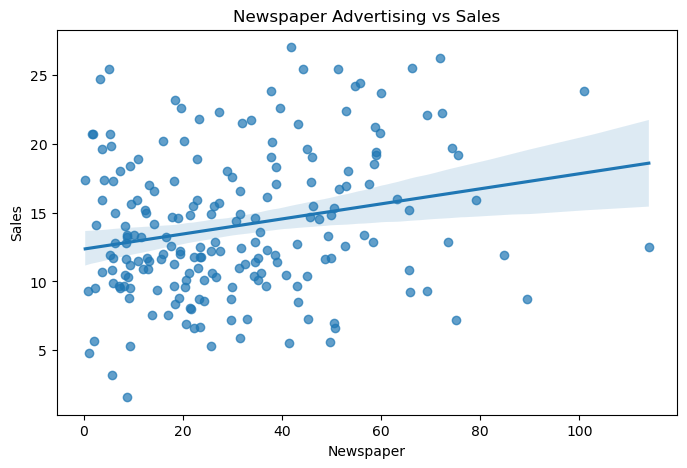

In [14]:
# Newspaper vs Sales
plt.figure(figsize=(8,5))

sns.regplot(
    data=df,
    x='Newspaper',
    y='Sales',
    scatter_kws={'alpha':0.7}
)

plt.title('Newspaper Advertising vs Sales')

plt.show()

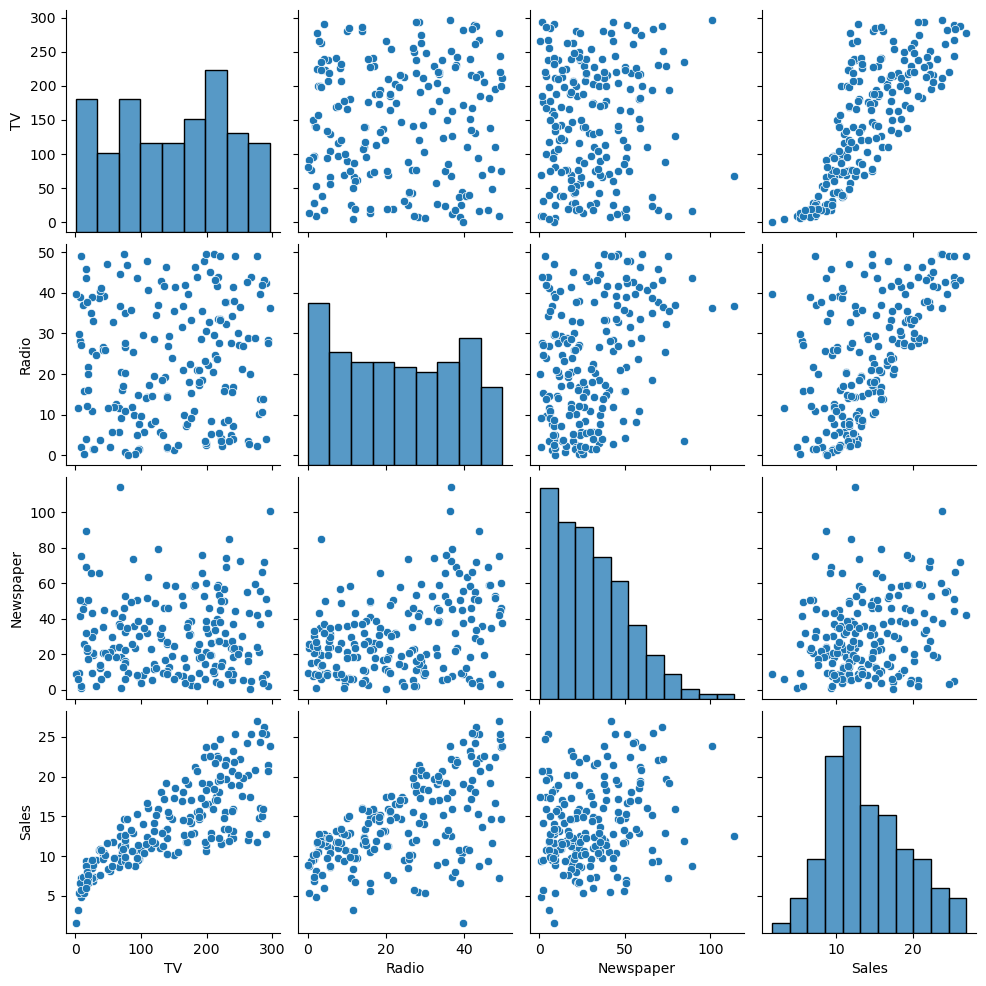

In [15]:
# Pairplot
sns.pairplot(df)

plt.show()

In [16]:
# Correlation with Target
sales_corr = df.corr(numeric_only=True)['Sales'].sort_values(ascending=False)

print(sales_corr)

Sales        1.000000
TV           0.782224
Radio        0.576223
Newspaper    0.228299
Name: Sales, dtype: float64


## Exploratory Data Analysis Summary

The analysis revealed that TV advertising is the strongest driver of sales, exhibiting a strong positive correlation of 0.782. Radio advertising also demonstrated a meaningful positive relationship with sales (0.576), while Newspaper advertising showed only a weak association (0.228).

Scatterplots confirmed approximately linear relationships between TV, Radio, and Sales, supporting the suitability of Linear Regression for modelling. Additionally, the predictor variables exhibited low inter-correlation, indicating the absence of multicollinearity issues.

Outlier analysis identified a few extreme Newspaper advertising values; however, these observations were retained as they likely represent legitimate marketing expenditures and do not significantly distort the dataset.

Overall, the exploratory analysis suggests that advertising expenditure, particularly on TV and Radio channels, plays a significant role in explaining variations in product sales.

In [17]:
# 4. Feature Engineering

#create Total_Advertising
df['Total_Advertising'] = (
    df['TV'] +
    df['Radio'] +
    df['Newspaper']
)

In [18]:
df.corr(numeric_only=True)['Sales'].sort_values(ascending=False)

Sales                1.000000
Total_Advertising    0.867712
TV                   0.782224
Radio                0.576223
Newspaper            0.228299
Name: Sales, dtype: float64

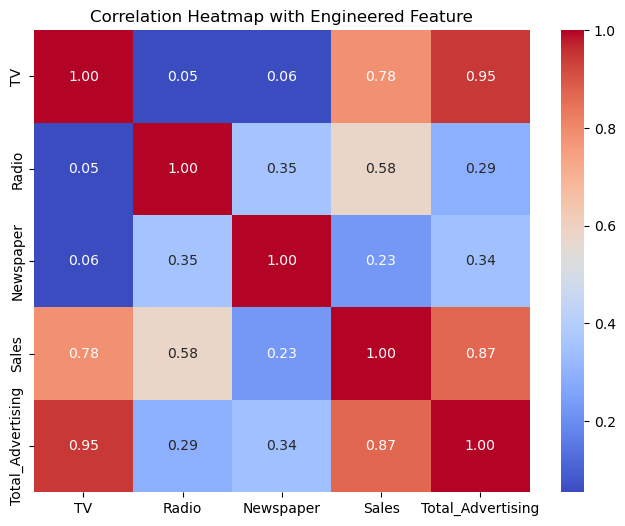

In [19]:
# check for multicollinearity
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap with Engineered Feature')

plt.show()

In [20]:
# Define Features
y = df["Sales"]

X_A = df[["TV", "Radio", "Newspaper"]]
X_B = df[["Total_Advertising"]]
X_C = df[["TV", "Radio"]]

In [22]:
from sklearn.model_selection import KFold, cross_validate

In [23]:
# Cross validation setup
model = LinearRegression()

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "r2": "r2",
    "mae": "neg_mean_absolute_error",
    "rmse": "neg_root_mean_squared_error"
}

In [24]:
#Evaluation Function

def evaluate_model(X, y, model_name):
    
    scores = cross_validate(
        model,
        X,
        y,
        cv=kf,
        scoring=scoring
    )
    
    return {
        "Model": model_name,
        "Mean R²": scores["test_r2"].mean(),
        "Mean MAE": -scores["test_mae"].mean(),
        "Mean RMSE": -scores["test_rmse"].mean(),
        "Std R²": scores["test_r2"].std()
    }

In [25]:
# Evaluate all model
results = []

results.append(evaluate_model(X_A, y, "TV + Radio + Newspaper"))
results.append(evaluate_model(X_B, y, "Total Advertising"))
results.append(evaluate_model(X_C, y, "TV + Radio"))

comparison_df = pd.DataFrame(results)

comparison_df = comparison_df.sort_values(
    by="Mean R²",
    ascending=False
).reset_index(drop=True)

comparison_df.round(4)


,Model,Mean R²,Mean MAE,Mean RMSE,Std R²
0,TV + Radio,0.8844,1.2796,1.6936,0.0391
1,TV + Radio + Newspaper,0.8827,1.2873,1.7057,0.0395
2,Total Advertising,0.7403,1.9669,2.5850,0.0437


In [26]:
# Final Model
X = df[['TV', 'Radio']]
y = df['Sales']

In [27]:
# Retrain model
from sklearn.linear_model import LinearRegression

final_model = LinearRegression()

final_model.fit(
    df[['TV', 'Radio']],
    df['Sales']
)

LinearRegression()

In [28]:
# Feature Importance
coef_df = pd.DataFrame({
    'Feature': ['TV', 'Radio'],
    'Coefficient': final_model.coef_
})

coef_df

,Feature,Coefficient
0,TV,0.045755
1,Radio,0.187994


Key Insight

Although TV has the strongest correlation with sales (0.782), Radio has the larger coefficient (0.188 vs 0.046).

This suggests:

TV advertising explains more overall variation in sales.
Radio advertising generates a larger marginal increase in sales per unit of spending.

In simple business terms:

TV appears to drive broad market awareness, while Radio provides a stronger incremental return for each additional advertising dollar invested.

# Model Equation
Sales = Intercept + (0.0458 × TV) + (0.1880 × Radio)

In [29]:
# Intercept
print(final_model.intercept_)

2.9210999124051362


Sales = 2.92 + (0.0458 × TV) + (0.1880 × Radio)

TV Advertising

For every additional £1 spent on TV advertising, sales are expected to increase by approximately 0.046 units, 
assuming Radio spending remains unchanged.

Radio Advertising

For every additional £1 spent on Radio advertising, sales are expected to increase by approximately 0.188 units, 
assuming TV spending remains unchanged.

# Final Conclusion

The TV + Radio model delivered the best performance, explaining approximately 88.4% of the variation in sales.
Newspaper advertising did not improve predictive accuracy and was removed from the final model. 
results indicate that TV and Radio are the most effective advertising channels for predicting product sales, with Radio providing the strongest incremental impact per unit of advertising spend.

# Save for Github

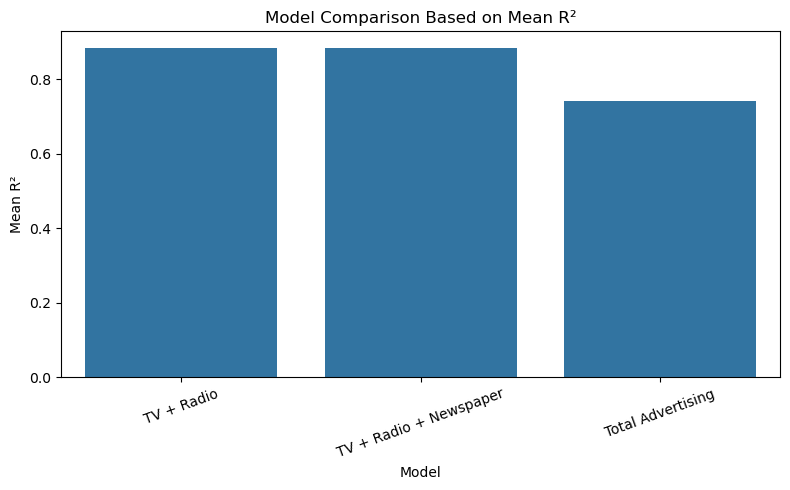

In [30]:
# Model Comparison Chart
plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison_df,
    x="Model",
    y="Mean R²"
)

plt.title("Model Comparison Based on Mean R²")
plt.xticks(rotation=20)
plt.tight_layout()

plt.savefig("visuals/model_comparison.png", dpi=300)
plt.show()

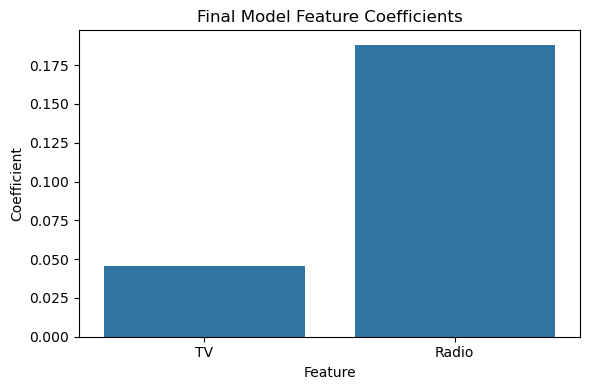

In [31]:
# Feature Coefficients Chart
plt.figure(figsize=(6,4))

sns.barplot(
    data=coef_df,
    x="Feature",
    y="Coefficient"
)

plt.title("Final Model Feature Coefficients")
plt.tight_layout()

plt.savefig("visuals/feature_coefficients.png", dpi=300)
plt.show()

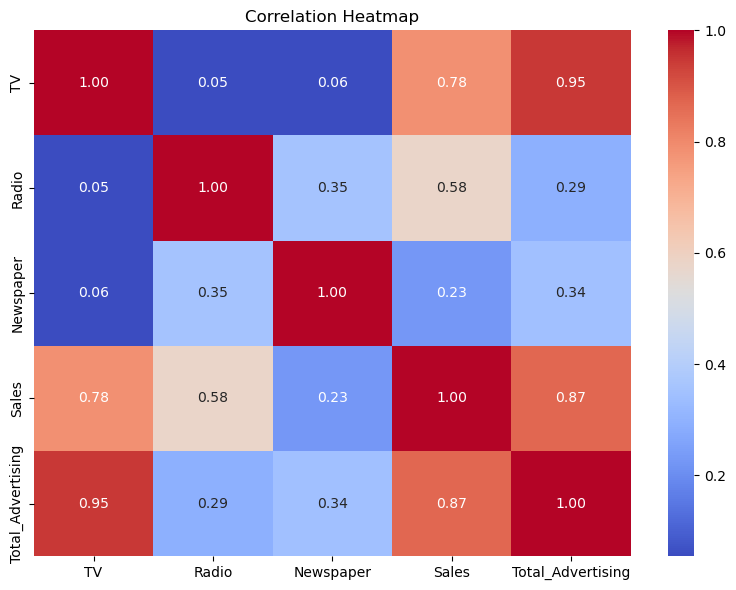

In [32]:
# Heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.tight_layout()

plt.savefig("visuals/correlation_heatmap.png", dpi=300)
plt.show()

In [33]:
# Save model
import joblib

joblib.dump(final_model, "sales_prediction_model.pkl")

['sales_prediction_model.pkl']